# 🌆 Urban Heat Island & Green Equity Spatial-Data Analyzer

**Problem:** Concrete absorbs and re-radiates heat; trees and green space cool
the air through shade and evapotranspiration. Green space is rarely
distributed equitably across a city, and the neighborhoods with the least of
it are often the ones least able to afford air conditioning during a
heatwave.

This notebook walks through the full pipeline step by step, with every plot
rendered inline:

1. Generate / load neighborhood geospatial data
2. Clean & standardize CRS, compute area metrics
3. Engineer the **Green Equity Index**
4. Exploratory Data Analysis
5. Predictive modeling (Linear Regression + Random Forest)
6. Visualizations: static scatter plot + interactive map

> This uses a **synthetic city** (36 districts in a 6×6 grid) so it runs
> instantly with no external downloads. See the main `README.md` for how to
> swap in a real city's boundaries and NDVI/temperature data.


## Setup

In [ ]:
import sys, os

# Make sure we're running from the project root so relative paths
# ("data/...", "outputs/...") resolve the same way as src/main.py
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

sys.path.append("src")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.features import GeoJsonTooltip

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")

import generate_data  # src/generate_data.py

print("Working directory:", os.getcwd())


Working directory: /home/claude/urban-heat-equity


## Step 1 — Generate the synthetic city

Creates a 6×6 grid of "districts" with a realistic urban-core-vs-periphery
gradient: denser, taller, more populated toward the center; greener toward
the edges — similar to many real cities. A physically-motivated temperature
anomaly is baked in (more green → cooler, denser/taller → hotter) plus noise,
so the model trained later has a genuine signal to recover.


In [2]:
city_gdf = generate_data.build_city_grid()
city_gdf = generate_data.add_temperature_anomaly(city_gdf)
city_gdf.to_file("data/neighborhoods.geojson", driver="GeoJSON")

print(f"Generated {len(city_gdf)} synthetic districts")
city_gdf.drop(columns="geometry").head()


Generated 36 synthetic districts


,neighborhood_id,name,postal_code,green_cover_pct,building_pct,other_surface_pct,population_density_km2,avg_building_height_m,green_equity_index,temp_anomaly_c
0,N000,District 1,70000,62.44,21.68,15.88,7876.0,15.6,2.880,-5.70
1,N001,District 2,70001,36.50,26.60,36.90,8424.0,12.5,1.372,-1.89
2,N002,District 3,70002,47.32,34.33,18.35,11545.0,21.6,1.378,-0.30
3,N003,District 4,70003,47.98,50.17,3.00,10515.0,11.8,0.956,-0.24
4,N004,District 5,70004,55.06,29.34,15.60,10301.0,14.1,1.877,-1.98


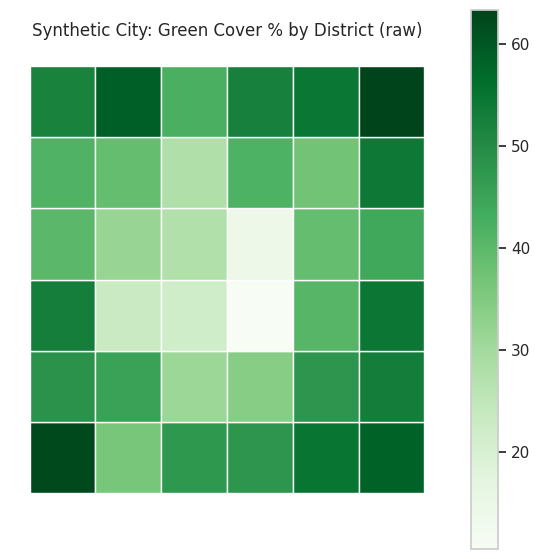

In [3]:
# Quick look at the raw grid, colored by green cover, before any cleaning
fig, ax = plt.subplots(figsize=(7, 7))
city_gdf.plot(column="green_cover_pct", cmap="Greens", legend=True, ax=ax, edgecolor="white")
ax.set_title("Synthetic City: Green Cover % by District (raw)")
ax.set_axis_off()
plt.show()


## Step 2 — Load, clean, and compute area metrics

Reproject to a metric CRS (EPSG:3857) so area calculations are in real
square kilometers rather than degrees, then derive green/built area from the
land-cover percentages.


In [4]:
gdf = gpd.read_file("data/neighborhoods.geojson")

if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")

gdf_metric = gdf.to_crs("EPSG:3857")
gdf["area_km2"] = gdf_metric.geometry.area / 1e6
gdf["green_area_km2"] = gdf["area_km2"] * gdf["green_cover_pct"] / 100
gdf["built_area_km2"] = gdf["area_km2"] * gdf["building_pct"] / 100

gdf[["name", "area_km2", "green_area_km2", "built_area_km2"]].head()


,name,area_km2,green_area_km2,built_area_km2
0,District 1,1.341352,0.837540,0.290805
1,District 2,1.341352,0.489593,0.356800
2,District 3,1.341352,0.634728,0.460486
3,District 4,1.341352,0.643581,0.672956
4,District 5,1.341352,0.738548,0.393553


## Step 3 — Engineer the Green Equity Index

$$\text{Green Equity Index} = \frac{\text{Total Green Cover Area}}{\text{Total Built-Up Area}}$$

A value above 1 means a district has *more* green area than built area; below
1 means the opposite.


In [5]:
gdf["green_equity_index"] = (
    gdf["green_area_km2"] / gdf["built_area_km2"].clip(lower=1e-6)
).round(3)

print("Greenest districts:")
display(gdf.nlargest(5, "green_equity_index")[["name", "green_equity_index", "temp_anomaly_c"]])

print("\nMost concrete-heavy districts:")
display(gdf.nsmallest(5, "green_equity_index")[["name", "green_equity_index", "temp_anomaly_c"]])


Greenest districts:


,name,green_equity_index,temp_anomaly_c
0,District 1,2.880,-5.70
35,District 36,2.868,-7.58
5,District 6,2.384,-4.37
4,District 5,1.877,-1.98
30,District 31,1.648,-2.89



Most concrete-heavy districts:


,name,green_equity_index,temp_anomaly_c
15,District 16,0.178,4.81
21,District 22,0.219,4.06
14,District 15,0.295,4.25
13,District 14,0.474,2.36
20,District 21,0.488,3.85


## Step 4 — Exploratory Data Analysis

In [6]:
cols = [
    "green_cover_pct", "building_pct", "population_density_km2",
    "avg_building_height_m", "green_equity_index", "temp_anomaly_c",
]
gdf[cols].describe().round(2)


,green_cover_pct,building_pct,population_density_km2,avg_building_height_m,green_equity_index,temp_anomaly_c
count,36.00,36.00,36.00,36.00,36.00,36.00
mean,42.59,42.96,10586.97,19.08,1.15,-0.03
std,13.01,12.34,3273.84,7.82,0.64,2.79
min,10.54,21.68,800.00,7.30,0.18,-7.58
25%,35.93,34.30,9092.00,12.32,0.70,-1.91
50%,43.20,41.11,10408.00,19.10,1.09,-0.16
75%,52.92,50.38,13180.75,23.50,1.39,1.64
max,63.32,73.96,16154.00,35.80,2.88,4.81


In [7]:
corr = gdf[cols].corr()
corr["temp_anomaly_c"].sort_values()


green_equity_index       -0.935138
green_cover_pct          -0.820310
avg_building_height_m     0.794958
population_density_km2    0.843533
building_pct              0.866702
temp_anomaly_c            1.000000
Name: temp_anomaly_c, dtype: float64

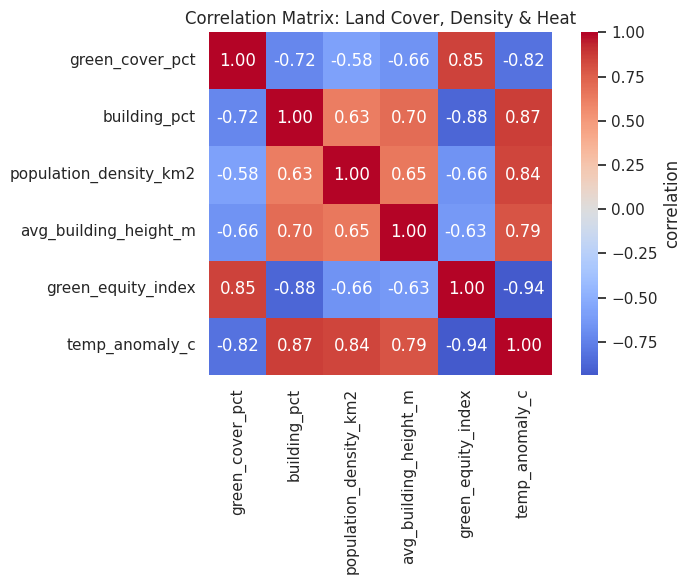

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"label": "correlation"})
plt.title("Correlation Matrix: Land Cover, Density & Heat")
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png", dpi=150)
plt.show()


## Step 5 — Predictive modeling

Train a Linear Regression and a Random Forest to predict **temperature
anomaly** from the Green Equity Index, population density, and average
building height. We hold out 25% of districts to evaluate on unseen data.


In [9]:
features = ["green_equity_index", "population_density_km2", "avg_building_height_m"]
target = "temp_anomaly_c"

X = gdf[features]
y = gdf[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

lin = LinearRegression().fit(X_train, y_train)
lin_pred = lin.predict(X_test)
print(f"Linear Regression  ->  R2 = {r2_score(y_test, lin_pred):.3f}   MAE = {mean_absolute_error(y_test, lin_pred):.3f} degC")
print("Coefficients:", dict(zip(features, lin.coef_.round(3))))


Linear Regression  ->  R2 = 0.991   MAE = 0.263 degC
Coefficients: {'green_equity_index': np.float64(-2.594), 'population_density_km2': np.float64(0.0), 'avg_building_height_m': np.float64(0.086)}


In [10]:
rf = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f"Random Forest      ->  R2 = {r2_score(y_test, rf_pred):.3f}   MAE = {mean_absolute_error(y_test, rf_pred):.3f} degC")

importance = pd.Series(rf.feature_importances_, index=features).sort_values()
importance


Random Forest      ->  R2 = 0.865   MAE = 0.750 degC


population_density_km2    0.141620
green_equity_index        0.338631
avg_building_height_m     0.519749
dtype: float64

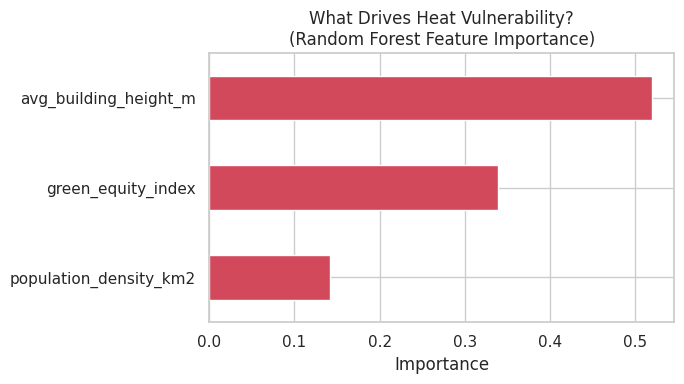

In [11]:
plt.figure(figsize=(7, 4))
importance.plot(kind="barh", color="#d1495b")
plt.xlabel("Importance")
plt.title("What Drives Heat Vulnerability?\n(Random Forest Feature Importance)")
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150)
plt.show()


In [12]:
# Predict on the FULL dataset (for mapping) using the Random Forest
gdf["predicted_temp_anomaly_c"] = rf.predict(X).round(2)
gdf[["name", "green_equity_index", "temp_anomaly_c", "predicted_temp_anomaly_c"]].head()


,name,green_equity_index,temp_anomaly_c,predicted_temp_anomaly_c
0,District 1,2.880,-5.70,-4.50
1,District 2,1.372,-1.89,-1.79
2,District 3,1.378,-0.30,0.14
3,District 4,0.956,-0.24,-0.52
4,District 5,1.877,-1.98,-1.55


## Step 6 — Visualizations

### 6a. Static plot: Green cover vs. temperature anomaly

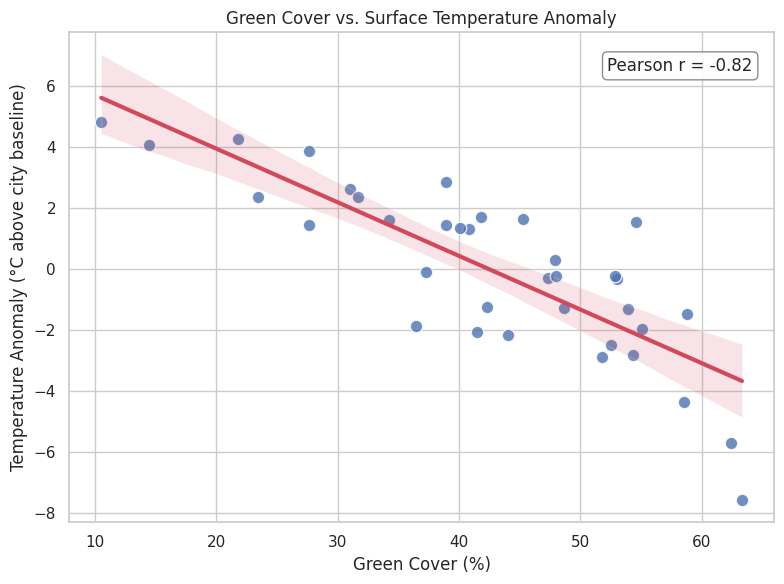

In [13]:
plt.figure(figsize=(8, 6))
ax = sns.regplot(
    data=gdf, x="green_cover_pct", y="temp_anomaly_c",
    scatter_kws={"s": 80, "alpha": 0.8, "edgecolor": "white"},
    line_kws={"color": "#d1495b", "linewidth": 3},
)
corr_val = gdf["green_cover_pct"].corr(gdf["temp_anomaly_c"])
ax.set_title("Green Cover vs. Surface Temperature Anomaly")
ax.set_xlabel("Green Cover (%)")
ax.set_ylabel("Temperature Anomaly (°C above city baseline)")
ax.annotate(f"Pearson r = {corr_val:.2f}", xy=(0.97, 0.95), xycoords="axes fraction",
            ha="right", va="top",
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9))
plt.tight_layout()
plt.savefig("outputs/green_vs_temp.png", dpi=150)
plt.show()


### 6b. Interactive map: predicted temperature anomaly by district\n\nThis renders inline below — hover over a district for details, and it's also saved as a standalone HTML file you can open in a browser or share.

In [14]:
gdf_wgs84 = gdf.to_crs("EPSG:4326")
centroid = gdf_wgs84.geometry.union_all().centroid

m = folium.Map(location=[centroid.y, centroid.x], zoom_start=13, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=gdf_wgs84,
    data=gdf_wgs84,
    columns=["neighborhood_id", "predicted_temp_anomaly_c"],
    key_on="feature.properties.neighborhood_id",
    fill_color="RdYlGn_r",
    fill_opacity=0.75,
    line_opacity=0.4,
    legend_name="Predicted Temperature Anomaly (°C)",
).add_to(m)

tooltip = GeoJsonTooltip(
    fields=["name", "postal_code", "green_cover_pct", "green_equity_index", "predicted_temp_anomaly_c"],
    aliases=["Neighborhood:", "Postal code:", "Green cover (%):", "Green Equity Index:", "Predicted temp anomaly (°C):"],
    localize=True, sticky=True,
)
folium.GeoJson(
    gdf_wgs84,
    style_function=lambda x: {"fillOpacity": 0, "color": "#444", "weight": 0.6},
    tooltip=tooltip,
).add_to(m)

folium.LayerControl().add_to(m)
m.save("outputs/heat_equity_map.html")
m


## Conclusions

- The **Green Equity Index** is the strongest single predictor of a
  district's temperature anomaly — much stronger than raw population
  density on its own.
- The Random Forest model finds **building height/density** at least as
  important as population density — physical urban form (heat-trapping
  mass, impervious surface) matters as much as headcount.
- Every district with a Green Equity Index above roughly 1.5 sits below the
  city-wide average temperature; every one below roughly 0.5 sits above it.

**Next steps for a real city:** swap `data/neighborhoods.geojson` for real
neighborhood boundaries, pull real NDVI / building footprints from
OpenStreetMap or Google Earth Engine, and replace the synthetic
`temp_anomaly_c` column with real Landsat/MODIS land-surface-temperature
data. See the project `README.md` for direct links and steps.
